# 02 - Limpieza y EDA

Este notebook limpia el dataset, documenta el diccionario de variables, hace un EDA breve
y guarda el dataset limpio en `data/processed/` y los graficos en `figures/`.


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

TARGET = 'produccion_toneladas'
FEATURES = ['año', 'id_municipio', 'subregion']
CULTIVO = 'Plátano'
SEED = 42

# Localizar la raiz del proyecto
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

DATA_RAW = ROOT / 'data' / 'raw'
DATA_PROCESSED = ROOT / 'data' / 'processed'
FIGURES = ROOT / 'figures'
for carpeta in (DATA_RAW, DATA_PROCESSED, FIGURES):
    carpeta.mkdir(parents=True, exist_ok=True)

ARCHIVO_RAW = DATA_RAW / 'Producción_de_frutales_en_el_Valle_del_Cauca_20260919.csv'

df = pd.read_csv(ARCHIVO_RAW, sep=',', encoding='utf-8')
print('Forma inicial:', df.shape)
df.head()


Forma inicial: (9992, 8)


,año,Id_municipio,Municipio,Subregion,Id_cultivo,Cultivo,Ciclo,Produccion_toneladas
0,2022,76233,Dagua,Sur,2045801,Plátano,Anual,14.088
1,2022,76100,Bolivar,Norte,2045801,Plátano,Anual,6.578
2,2022,76243,El Aguila,Norte,2045801,Plátano,Anual,26.000
3,2022,76001,Cali,Sur,2045801,Plátano,Anual,186
4,2022,76275,Florida,Sur,2045801,Plátano,Anual,"2.124,4"


## 2.1 Limpieza basica


In [33]:
# Renombrar columnas: normalizar a minusculas (quita mayusculas y espacios)
df.columns = [c.strip().lower() for c in df.columns]
print('Columnas normalizadas:', df.columns.tolist())


Columnas normalizadas: ['año', 'id_municipio', 'municipio', 'subregion', 'id_cultivo', 'cultivo', 'ciclo', 'produccion_toneladas']


Se normalizan los nombres a minusculas (`Id_municipio` -> `id_municipio`, etc.) para facilitar
su uso y que coincidan con las constantes `TARGET`/`FEATURES`.


In [34]:
# Seleccionar solo el cultivo con mas datos (definido en las constantes)
df = df[df['cultivo'] == CULTIVO].copy()
print('Filas tras filtrar cultivo =', CULTIVO, ':', df.shape)

# Eliminar filas duplicadas (defensivo; en Plátano no las hay)
df = df.drop_duplicates()

# Columnas que no se usan:
#  - municipio: texto duplicado del id_municipio.
#  - cultivo / id_cultivo: constantes tras el filtro.
#  - ciclo: para Plátano es siempre 'Anual' (constante).
df = df.drop(columns=['municipio', 'cultivo', 'id_cultivo', 'ciclo'])

print('Nulos totales:', df.isnull().sum().sum())


Filas tras filtrar cultivo = Plátano : (943, 8)
Nulos totales: 0


**Justificacion**: se conserva solo Plátano (el cultivo con mas datos) para no mezclar especies
distintas en un mismo modelo. Al filtrar, `cultivo`, `id_cultivo` y `ciclo` quedan constantes y se
eliminan; `municipio` es texto duplicado del id. No hay nulos, asi que no se imputa nada.


In [35]:
# produccion_toneladas usa formato español: punto = miles, coma = decimal.
# 1) quitar puntos de miles, 2) cambiar coma por punto, 3) convertir a float.
df['produccion_toneladas'] = (
    df['produccion_toneladas']
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# Identificadores y año como enteros
df['año'] = df['año'].astype(int)
df['id_municipio'] = df['id_municipio'].astype(int)

print(df.dtypes)


año                       int64
id_municipio              int64
subregion                object
produccion_toneladas    float64
dtype: object


**Paso clave**: `produccion_toneladas` venia como texto con separador de miles (punto) y decimal
(coma), por ejemplo `2.124,4`. Primero se quitan los puntos y luego se reemplaza la coma por
punto, para convertirla a numero (`2124.4`).


In [36]:
# Tratamiento de nulos. En este dataset no hay nulos, pero se define la regla:
#  - Numericas: imputar con la mediana (robusta ante valores extremos).
#  - Categoricas: eliminar la fila.
print('Nulos tras transformaciones:', df.isnull().sum().sum())

for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype.kind in 'if':
            df[col] = df[col].fillna(df[col].median())
        else:
            df = df.dropna(subset=[col])

print('Nulos despues del tratamiento:', df.isnull().sum().sum())


Nulos tras transformaciones: 0
Nulos despues del tratamiento: 0


**Justificacion**: al no haber nulos no se aplica ninguna imputacion. Si los hubiera, se usa la
mediana para las variables numericas porque no se ve afectada por los valores extremos de la
produccion (a diferencia de la media).


In [37]:
# Conservamos objetivo y predictores (orden estable)
df = df[[TARGET] + FEATURES]

print('Valores de produccion iguales a 0:', (df[TARGET] == 0).sum())
print('Forma final:', df.shape)
df.head()


Valores de produccion iguales a 0: 0
Forma final: (943, 4)


,produccion_toneladas,año,id_municipio,subregion
0,14088.0,2022,76233,Sur
1,6578.0,2022,76100,Norte
2,26000.0,2022,76243,Norte
3,186.0,2022,76001,Sur
4,2124.4,2022,76275,Sur


Para Plátano no hay registros con produccion igual a 0; no es necesario tratar valores nulos ni
ceros.


## 2.2 Diccionario de variables

| Variable | Descripcion | Tipo | Rol |
| --- | --- | --- | --- |
| produccion_toneladas | Toneladas de fruta producidas | numerica (float) | Objetivo |
| año | Año del registro (2000-2022) | numerica (int) | Predictor |
| id_municipio | Identificador numerico del municipio | numerica (int) | Predictor |
| subregion | Region geografica (Centro, Norte, Pacifico, Sur) | categorica | Predictor |


## 2.3 EDA breve


        produccion_toneladas          año  id_municipio subregion
count             943.000000   943.000000    943.000000       943
unique                   NaN          NaN           NaN         4
top                      NaN          NaN           NaN     Norte
freq                     NaN          NaN           NaN       368
mean             5346.897720  2010.882291  76413.864263       NaN
std              9997.690764     6.651783    300.463302       NaN
min                33.000000  2000.000000  76001.000000       NaN
25%               775.000000  2005.000000  76126.000000       NaN
50%              1978.000000  2011.000000  76364.000000       NaN
75%              4771.000000  2017.000000  76670.000000       NaN
max            105000.000000  2022.000000  76895.000000       NaN


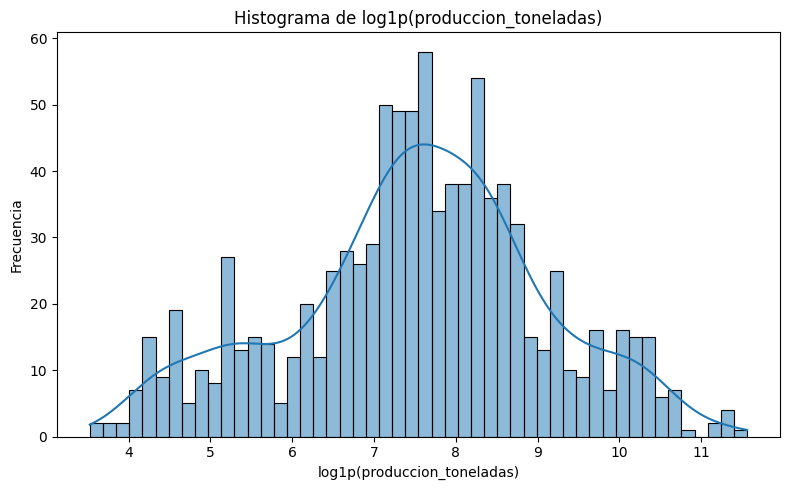

In [38]:
# Estadisticos basicos (numericas y categoricas)
print(df.describe(include='all'))

# Histograma de la variable objetivo
# La produccion esta muy sesgada; log1p comprime la escala para ver la forma.
plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(df[TARGET]), bins=50, kde=True)
plt.title('Histograma de log1p(produccion_toneladas)')
plt.xlabel('log1p(produccion_toneladas)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.savefig(FIGURES / 'histograma_objetivo.png', dpi=150)
plt.show()


Se usa `log1p` (log(1+x)) para ver la forma: la produccion de Plátano es asimetrica hacia la
derecha, con muchas producciones pequenas (mediana ~1978 t) y pocas muy grandes (maximo ~105000 t).


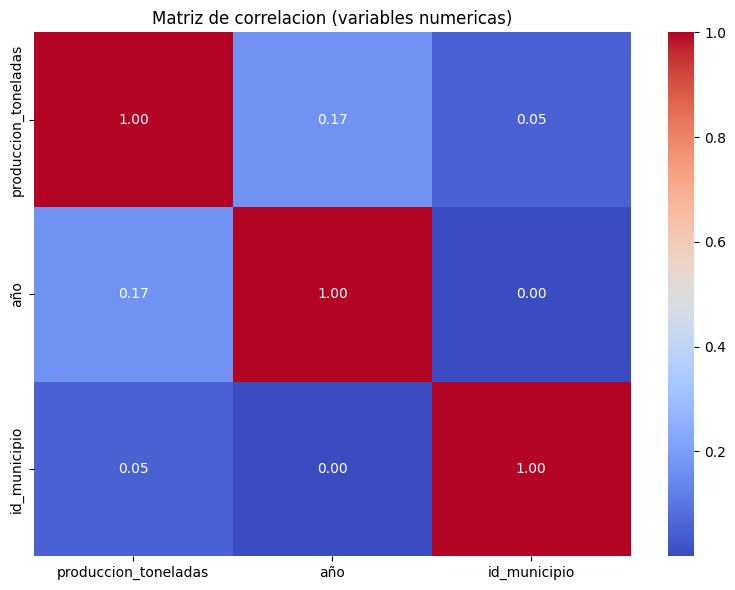

In [39]:
# Matriz de correlacion: solo variables numericas
cols_num = [c for c in ([TARGET] + FEATURES) if df[c].dtype.kind in 'if']

plt.figure(figsize=(8, 6))
sns.heatmap(df[cols_num].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlacion (variables numericas)')
plt.tight_layout()
plt.savefig(FIGURES / 'matriz_correlacion.png', dpi=150)
plt.show()


La correlacion de las variables numericas (`año`, `id_municipio`) con la produccion suele ser
baja; un valor cercano a 0 indica relacion lineal debil. Tambien conviene verificar que la
correlacion entre predictores sea baja (para evitar multicolinealidad).


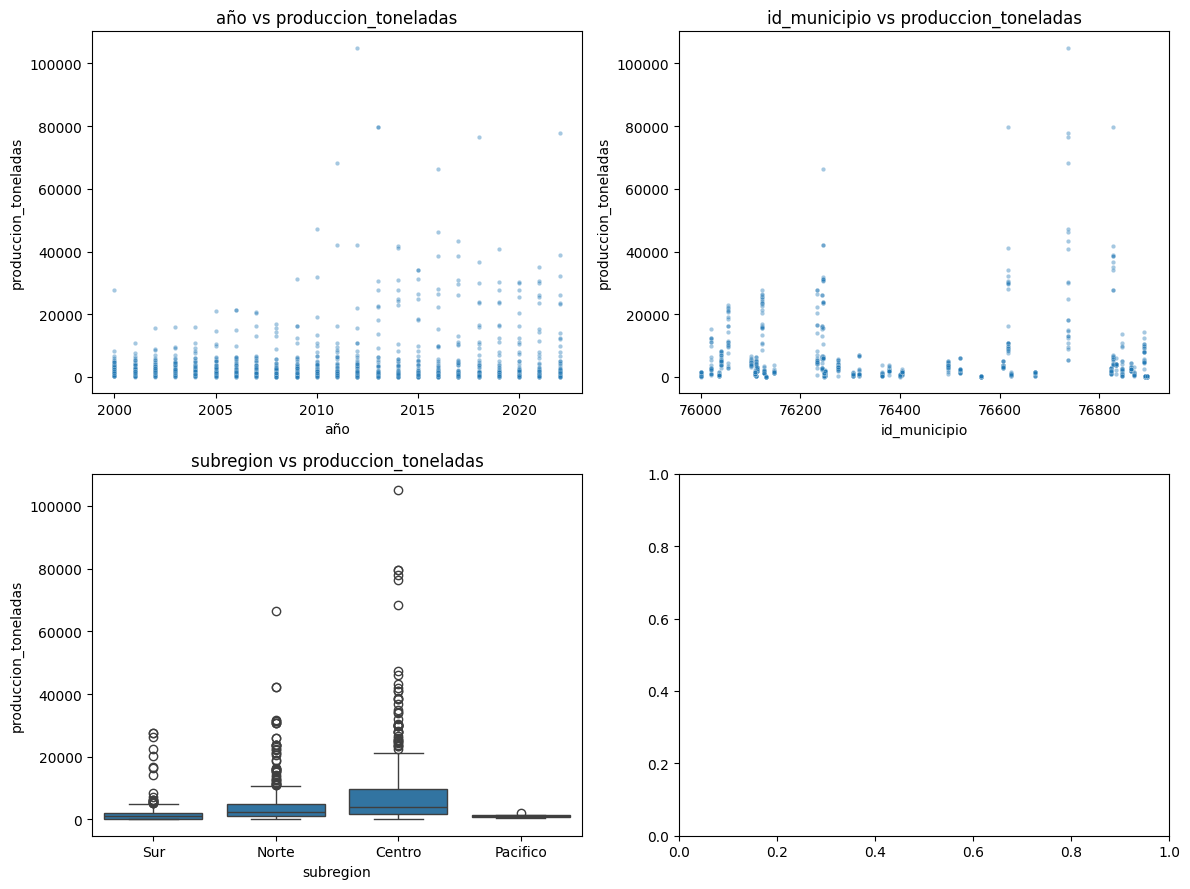

In [40]:
# Relacion de cada predictor con el objetivo:
# numericas -> scatter; categoricas -> boxplot.
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col in zip(axes.flat, FEATURES):
    if df[col].dtype.kind in 'if':
        sns.scatterplot(data=df, x=col, y=TARGET, ax=ax, alpha=0.4, s=10)
    else:
        sns.boxplot(data=df, x=col, y=TARGET, ax=ax)
    ax.set_title(f'{col} vs {TARGET}')
plt.tight_layout()
plt.savefig(FIGURES / 'scatter_predictores_objetivo.png', dpi=150)
plt.show()


Los graficos no muestran una relacion lineal clara: las numericas forman nubes de puntos y el
boxplot de `subregion` tiene medianas parecidas entre categorias.


In [41]:
# Guardar dataset limpio
SALIDA = DATA_PROCESSED / 'frutales_limpias.csv'
df.to_csv(SALIDA, index=False)
print('Dataset limpio guardado en:', SALIDA)
print('Forma:', df.shape)


Dataset limpio guardado en: D:\Universidad\Alejandro\Taller_001\data\processed\frutales_limpias.csv
Forma: (943, 4)


**Resumen**: se paso de 9 992 filas x 8 columnas a 943 filas x 4 columnas (solo Plátano). Se
filtraron las filas del cultivo elegido y se eliminaron `municipio`, `cultivo`, `id_cultivo` y
`ciclo` (constantes); se convirtio la produccion a numero y se conservaron el objetivo y los 3
predictores.
